# Spectral fitting example (AGN)


This notebook fits the spectrum of a simulated AGN observation with COSI using the same 3ML workflow as the Crab spectral fitting tutorial.

The binned mock data already include NGC 4151 plus background. The fit uses the mock histogram as the observed data and uses `mock - NGC4151` as the fitted background template, with NGC 4151 modeled as a cutoff-power-law thermal component plus an optional simple-power-law non-thermal tail.


In [43]:
from cosipy import BinnedData
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.event_selection import GoodTimeInterval
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file

from cosipy.statistics import PoissonLikelihood
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import BinnedThreeMLModelFolding, BinnedInstrumentResponse, BinnedThreeMLPointSourceResponse
from cosipy.data_io import EmCDSBinnedData

from histpy import Histogram

import sys

import astropy.units as u
from astropy.coordinates import SkyCoord

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from threeML import PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter, Cutoff_powerlaw, Powerlaw, Line

from pathlib import Path

%matplotlib inline


## Download and read in binned data


Define the paths to the mock data, original NGC 4151 data, detector response, orientation file, and yaml configuration. The mock data are expected to be binned before running this notebook.


In [ ]:
analysis_dir = Path.cwd()
if not (analysis_dir / "agn.yaml").exists():
    repo_notebook_dir = Path("/Users/parshadkp/Software/cosipy/docs/tutorials/spectral_fits/continuum_fit/AGN")
    if repo_notebook_dir.exists():
        analysis_dir = repo_notebook_dir

# binned_mock_data_file = Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Mock_Data/Mock_Data_Cut/mock_with_updated_NGC4151_FluxNTH_0p35_time_cut.hdf5")
# NGC4151_file = Path("/Users/parshadkp/Software/COSI_Data/DC4_Files/NGC_4151_ec200_0p35_DC3_COSI_cpl_pl_time_cut_in_fov.hdf5")

# binned_mock_data_file = Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Mock_Data/Mock_Data_Cut/mock_with_updated_NGC4151_FluxNTH_0p25_time_cut.hdf5")
# NGC4151_file = Path("/Users/parshadkp/Software/COSI_Data/DC4_Files/NGC_4151_ec200_0p25_DC4_COSI_cpl_pl_time_cut_in_fov.hdf5")

binned_mock_data_file = Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Mock_Data/Mock_Data_Cut/mock_with_updated_NGC4151_FluxNTH_0p30_time_cut.hdf5")
NGC4151_file = Path("/Users/parshadkp/Software/COSI_Data/DC4_Files/NGC_4151_ec200_0p30_DC4_COSI_cpl_pl_time_cut_in_fov.hdf5")

# binned_mock_data_file = Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Mock_Data/Mock_Data_Cut/mock_with_updated_NGC4151_FluxNTH_0p15_time_cut.hdf5")
# NGC4151_file = Path("/Users/parshadkp/Software/COSI_Data/DC4_Files/NGC_4151_ec200_DC4_COSI_cpl_pl_fluxNTH_0p15_time_cut_in_fov.hdf5")

# binned_mock_data_file = Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Mock_Data/Mock_Data_Cut/dc4_mock_dataset_3months_unbinned_data_filtered_with_SAAcut_time_ordered_ngc4151_in_fov_binned.hdf5")
# NGC4151_file = Path("/Users/parshadkp/Software/COSI_Data/DC4_Files/NGC_4151__3months_unbinned_data_filtered_with_SAAcut_ngc4151_in_fov_binned.hdf5")

orientation_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori"
response_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"
agn_config = analysis_dir / "agn.yaml"

exposure_multiplier = 8
exposure_months = exposure_multiplier * 3

# Toggle whether the response uses the NGC 4151 FOV-cut spacecraft history.
use_time_cut_orientation = True
include_nonthermal_tail = True
tail_ratio_at_200keV = 0.30
max_offaxis = 60 * u.deg
earth_occ = True

source_label = "NGC 4151"
source_l = 155.07 * u.deg
source_b = 75.06 * u.deg
source_coord = SkyCoord(l=source_l, b=source_b, frame="galactic")

In [ ]:
total_mock_data = Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Mock_Data/Mock_Data_Cut/mock_with_updated_NGC4151_FluxNTH_0p15_time_cut.hdf5")
background_DC4 = Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Background/Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck_ngc4151_in_fov_binned.hdf5")
background_DC4_old = Path("/Users/parshadkp/Software/COSI_Data/DC4_Files/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_NGC4151_TimeCut.hdf5")
NGC_4151_old = Path("/Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/Paper_Models/NGC_4151_ec200_DC3_COSI_cpl_pl.hdf5")
NGC_4151_DC4 = Path("/Users/parshadkp/Software/COSI_Data/DC4_Files/NGC_4151__3months_binned_data_filtered_with_SAAcut.hdf5")
full_mock_data = Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Mock_Data/dc4_mock_dataset_3months_binned_data_filtered_with_SAAcut_time_ordered.hdf5")

FONT_SIZE = 30
plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update({
    "font.weight": "550",
    "axes.titleweight": "550",
    "axes.labelweight": "550",
})

total_mock_data = Histogram.open(total_mock_data)
background_DC4 = Histogram.open(background_DC4)
background_DC4_old = Histogram.open(background_DC4_old)
NGC_4151_hist_comp = Histogram.open(NGC4151_file)
NGC_4151_hist_old = Histogram.open(NGC_4151_old)
NGC_4151_hist_DC4 = Histogram.open(NGC_4151_DC4)
full_mock_data_hist = Histogram.open(full_mock_data)
NGC_4151_hist_comp_2 = Histogram.open(NGC4151_file_2)
total_mock_data_2 = Histogram.open(binned_mock_data_file_2)


def projection_counts(hist, axis_name):
    return hist.project(axis_name).to_dense(copy=False).contents


def style_axis(ax):
    ax.xaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", top=True, pad=8, labelsize=FONT_SIZE)
    ax.xaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", top=True, pad=8)
    ax.yaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", right=True, pad=8, labelsize=FONT_SIZE)
    ax.yaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", right=True, pad=8)
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)

mock_data_counts = projection_counts(total_mock_data, "Em")
mock_data_counts_2 = projection_counts(total_mock_data_2, "Em")
background_DC4_counts = projection_counts(background_DC4, "Em")
background_DC4_old_counts = projection_counts(background_DC4_old, "Em")
source_counts = projection_counts(NGC_4151_hist_comp, "Em")
source_counts_2 = projection_counts(NGC_4151_hist_comp_2, "Em")
source_old_counts = projection_counts(NGC_4151_hist_old, "Em")
source_DC4_counts = projection_counts(NGC_4151_hist_DC4, "Em")
full_mock_data_counts = projection_counts(full_mock_data_hist, "Em")

total_source_counts = source_counts.sum() * exposure_multiplier
total_source_old_counts = source_old_counts.sum() * exposure_multiplier
total_mock_data_counts = mock_data_counts.sum() * exposure_multiplier
total_background_counts = background_DC4_old_counts.sum() * exposure_multiplier
sigma = total_source_counts / np.sqrt(total_mock_data_counts)
sigma_old = total_source_old_counts / np.sqrt(total_source_old_counts + total_background_counts)
sigma_full = total_source_counts / np.sqrt(full_mock_data_counts.sum() * exposure_multiplier)

# print(f"Source counts: {total_source_counts:,.3g}")
# print(f"Background counts: {total_mock_data_counts:,.3g}")
print(f"Sigma (Mock Data): {sigma:.3f}")
print(f"Sigma (Single Source): {sigma_old:.3f}")
print(f"Sigma (Full Mock Data): {sigma_full:.3f}")

mock_data_edges = total_mock_data.axes["Em"].edges.to_value(u.keV)
background_DC4_edges = background_DC4.axes["Em"].edges.to_value(u.keV)

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)
# ax.stairs(background_DC4_counts, background_DC4_edges / 1000, label="DC4 Background (Time Cut)", color="black", linestyle="dashdot")
ax.stairs(full_mock_data_counts, mock_data_edges / 1000, label="DC4 Mock Data (Full)", color="black", linestyle="solid")
ax.stairs(mock_data_counts, mock_data_edges / 1000, label="DC4 Mock Data (Time Cut)", color="red", linestyle="dashed")
ax.stairs(source_old_counts, mock_data_edges / 1000, label="NGC 4151 (Full)", color="green", linestyle="solid")
ax.stairs(source_counts, mock_data_edges / 1000, label="NGC 4151 (Time Cut)", color="blue", linestyle="dashed")
# ax.stairs(source_DC4_counts, mock_data_edges / 1000, label="NGC 4151 (DC4)", color="blue", linestyle="dashed")
# ax.stairs(source_counts_2, mock_data_edges / 1000, label="NGC 4151 (Time Cut, FluxNTH=0.35)", color="orange", linestyle="dashed")
# ax.stairs(source_counts, mock_data_edges / 1000, label="NGC 4151 (Time Cut, FluxNTH=0.15)", color="blue", linestyle="dashed")
# ax.stairs(mock_data_counts, mock_data_edges / 1000, label="DC4 Mock Data (Time Cut, FluxNTH=0.15)", color="red", linestyle="dashed")
# ax.stairs(mock_data_counts_2, mock_data_edges / 1000, label="DC4 Mock Data (Time Cut, FluxNTH=0.35)", color="black", linestyle="dashed")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_ylabel("Counts", fontsize=FONT_SIZE)
ax.set_ylim(1e6, 1e8)
ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))
ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.legend(fontsize=20, loc=(0.07, 0.02), frameon=False)

Exception ignored in: <function WeakValueDictionary.__init__.<locals>.remove at 0x11ec8ad40>
Traceback (most recent call last):
  File "/Users/parshadkp/.pyenv/versions/3.12.8/lib/python3.12/weakref.py", line 105, in remove
    def remove(wr, selfref=ref(self), _atomic_removal=_remove_dead_weakref):

KeyboardInterrupt: 


NameError: name 'NGC4151_file_2' is not defined

Read in the spacecraft orientation file.


In [190]:
# fetch_wasabi_file(
#     "COSI-SMEX/DC2/Data/Orientation/20280301_3_month_with_orbital_info.ori",
#     output=str(orientation_path),
#     checksum="416fcc296fc37a056a069378a2d30cb2",
# )
sc_orientation_full = SpacecraftHistory.open(orientation_path)
full_livetime = sc_orientation_full.cumulative_livetime().to_value(u.s)

if use_time_cut_orientation:
    source_gti = GoodTimeInterval.from_pointing_cut(
        source_coord,
        sc_orientation_full,
        max_offaxis,
        earth_occ=earth_occ,
    )
    sc_orientation = sc_orientation_full.apply_gti(source_gti)
    orientation_label = f"{source_label} FOV-cut .ori"
    orientation_color = "red"
else:
    sc_orientation = sc_orientation_full
    orientation_label = "Full .ori"
    orientation_color = "blue"

selected_livetime = sc_orientation.cumulative_livetime().to_value(u.s)

print(f"Full orientation livetime: {full_livetime:,.1f} s")
print(f"Selected orientation: {orientation_label}")
print(f"Selected orientation livetime: {selected_livetime:,.1f} s")
print(f"Selected/full livetime fraction: {selected_livetime / full_livetime:.4f}")


Full orientation livetime: 6,579,555.0 s
Selected orientation: NGC 4151 FOV-cut .ori
Selected orientation livetime: 980,415.0 s
Selected/full livetime fraction: 0.1490


Load the binned mock data and original NGC 4151 histogram. The mock histogram is the observed data, and `mock - NGC4151` is used as the fitted background template.


In [191]:
if not binned_mock_data_file.exists():
    raise FileNotFoundError(
        f"Set binned_mock_data_file to your binned mock data HDF5 file: {binned_mock_data_file}"
    )
if not NGC4151_file.exists():
    raise FileNotFoundError(
        f"Set NGC4151_file to your original binned NGC 4151 HDF5 file: {NGC4151_file}"
    )

mock = Histogram.open(binned_mock_data_file)
NGC4151 = Histogram.open(NGC4151_file)

data_hist = mock.project("Em", "Phi", "PsiChi") * exposure_multiplier
ngc4151_hist = NGC4151.project("Em", "Phi", "PsiChi") * exposure_multiplier
total_bkg = data_hist - ngc4151_hist


def make_background_distribution():
    # Build a fresh copy for each fit because FreeNormBinnedBackground normalizes its input.
    total_bkg_for_fit = total_bkg.copy()
    total_bkg_for_fit += sys.float_info.min
    return {"total_bkg": total_bkg_for_fit}


Fetch and open the response.


In [192]:
# fetch_wasabi_file(
#     "COSI-SMEX/develop/Data/Responses/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5",
#     output=str(response_path),
#     checksum="7121f094be50e7bfe9b31e53015b0e85",
# )
dr = FullDetectorResponse.open(str(response_path))


## Perform spectral fit


Define a helper that sets the background parameter and instantiates the COSI 3ML plugin for the selected spacecraft history.


In [193]:
def build_cosi_plugin(sc_orientation, plugin_name="cosi"):
    # Wrap the raw BinnedData object into the appropriate data interface.
    data = EmCDSBinnedData(data_hist)

    # Use the background model to initialize a background expectation interface.
    bkg = FreeNormBinnedBackground(make_background_distribution(),
                                   sc_history=sc_orientation,
                                   copy=False)

    # Wrap the raw response with the BinnedInstrumentResponse interface implementation.
    instrument_response = BinnedInstrumentResponse(dr, data)

    # Initialize the 3ML point-source response.
    psr = BinnedThreeMLPointSourceResponse(data=data,
                                           instrument_response=instrument_response,
                                           sc_history=sc_orientation,
                                           energy_axis=dr.axes["Ei"],
                                           polarization_axis=dr.axes["Pol"] if "Pol" in dr.axes.labels else None,
                                           nside=2 * data.axes["PsiChi"].nside)

    # Pass the 3ML point-source response to the interface implementation that performs the folding with the spectrum.
    response = BinnedThreeMLModelFolding(data=data, point_source_response=psr)

    # Likelihood to use.
    like_fun = PoissonLikelihood(data, response, bkg)

    # Initialize 3ML plugin.
    cosi = ThreeMLPluginInterface(plugin_name,
                                  like_fun,
                                  response,
                                  bkg)

    # Initialize background parameters, considered as nuisance parameters.
    for bkg_label in bkg.labels:
        cosi.bkg_parameter[bkg_label] = Parameter(bkg_label,
                                                  200.0,
                                                  min_value=0.0,
                                                  max_value=10000.0,
                                                  delta=0.05,
                                                  unit=u.Hz)

    return {
        "data": data,
        "bkg": bkg,
        "instrument_response": instrument_response,
        "psr": psr,
        "response": response,
        "cosi": cosi,
    }


Define NGC 4151 at the known location with a cutoff-power-law thermal component and an optional power-law tail in a single composite point-source model.


Build the plugin and model for the CPL+PL and CPL-only hypotheses, combine each with a JointLikelihood object, and perform the maximum likelihood fits.


In [194]:
K_inj = (0.15 * exposure_multiplier) / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.75

spectrum_inj_ec200 = Cutoff_powerlaw()

spectrum_inj_ec200.K.value = K_inj.value
spectrum_inj_ec200.piv.value = piv_inj.value
spectrum_inj_ec200.xc.value = xc_inj.value
spectrum_inj_ec200.index.value = index_inj

spectrum_inj_ec200.K.unit = K_inj.unit
spectrum_inj_ec200.piv.unit = piv_inj.unit
spectrum_inj_ec200.xc.unit = xc_inj.unit

K_inj = tail_ratio_at_200keV * spectrum_inj_ec200.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -3.8

spectrum_inj_ec200_PL = Powerlaw()

spectrum_inj_ec200_PL.K.value = K_inj.value
spectrum_inj_ec200_PL.piv.value = piv_inj.value
spectrum_inj_ec200_PL.index.value = index_inj

spectrum_inj_ec200_PL.K.unit = K_inj.unit
spectrum_inj_ec200_PL.piv.unit = piv_inj.unit

spectrum_inj_ec200_total = spectrum_inj_ec200 + spectrum_inj_ec200_PL

In [195]:
def build_ngc4151_model(include_tail=None):
    if include_tail is None:
        include_tail = include_nonthermal_tail

    # Give it some harsher initial guesses.
    index = -1.75
    reference_piv = 1. * u.keV
    piv = 200. * u.keV
    K = (
        (0.15 * exposure_multiplier)
        * (piv / reference_piv).to_value(u.dimensionless_unscaled) ** index
    ) / u.cm / u.cm / u.s / u.keV
    xc = 200. * u.keV

    spectrum_cpl = Cutoff_powerlaw()

    spectrum_cpl.K.value = K.value
    spectrum_cpl.piv.value = piv.value
    spectrum_cpl.xc.value = xc.value
    spectrum_cpl.index.value = index
    spectrum_cpl.index.fix = True

    # Keep the hard bounds broad enough that covariance samples are not clipped.
    spectrum_cpl.K.min_value = 1e-8
    spectrum_cpl.K.max_value = 1e-2
    spectrum_cpl.xc.min_value = 100
    spectrum_cpl.xc.max_value = 10000

    spectrum_cpl.K.unit = K.unit
    spectrum_cpl.piv.unit = piv.unit
    spectrum_cpl.xc.unit = xc.unit

    spectral_shape = spectrum_cpl
    tail_link_ratio = None

    if include_tail:
        # Put the tail in the same point source as the thermal component.
        # This matches the injected model structure and avoids fitting two linked point sources at the same sky position.
        K_tail = tail_ratio_at_200keV * spectrum_cpl.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
        piv_tail = 200. * u.keV
        index_tail = -3.8

        spectrum_tail = Powerlaw()
        spectrum_tail.K.value = K_tail.value
        spectrum_tail.piv.value = piv_tail.value
        spectrum_tail.index.value = index_tail

        spectrum_tail.K.min_value = 1e-12
        spectrum_tail.K.max_value = 10
        spectrum_tail.index.min_value = -5
        spectrum_tail.index.max_value = -2
        spectrum_tail.index.delta = 0.25

        spectrum_tail.K.unit = K_tail.unit
        spectrum_tail.piv.unit = piv_tail.unit

        tail_link_ratio = K_tail.value / spectrum_cpl.K.value

        spectral_shape = spectrum_cpl + spectrum_tail

    ngc4151 = PointSource("ngc4151",
                          l=source_l.to_value(u.deg),
                          b=source_b.to_value(u.deg),
                          spectral_shape=spectral_shape)

    model = Model(ngc4151)

    if include_tail:
        link_function = Line(a=0.0, b=tail_link_ratio)
        link_function.a.fix = True
        link_function.b.min_value = 0.0
        link_function.b.max_value = 1.0
        link_function.b.delta = max(abs(tail_link_ratio) * 0.1, 1e-8)
        model.link(
            model.ngc4151.spectrum.main.composite.K_2,
            model.ngc4151.spectrum.main.composite.K_1,
            link_function,
        )

    return model


In [196]:
def fit_ngc4151_hypothesis(label, plugin_name, include_tail, color, linestyle):
    print(f"\nFitting {label} ...")

    fit = {
        "label": label,
        "sc_orientation": sc_orientation,
        "include_nonthermal_tail": include_tail,
        "color": color,
        "linestyle": linestyle,
    }
    fit.update(build_cosi_plugin(sc_orientation, plugin_name=plugin_name))
    fit["model"] = build_ngc4151_model(include_tail=include_tail)
    fit["plugins"] = DataList(fit["cosi"])
    fit["like"] = JointLikelihood(fit["model"], fit["plugins"], verbose=False)

    _ = fit["like"].fit()
    fit["results"] = fit["like"].results
    fit["expectation"] = fit["response"].expectation()

    return fit


cpl_pl_fit = fit_ngc4151_hypothesis(
    f"{orientation_label} CPL + PL",
    plugin_name="cosi_cpl_pl",
    include_tail=True,
    color=orientation_color,
    linestyle="dashdot",
)
cpl_only_fit = fit_ngc4151_hypothesis(
    f"{orientation_label} CPL only",
    plugin_name="cosi_cpl_only",
    include_tail=False,
    color="black",
    linestyle="dashed",
)

primary_fit = cpl_pl_fit

data = primary_fit["data"]
bkg = primary_fit["bkg"]
response = primary_fit["response"]
cosi = primary_fit["cosi"]
like = primary_fit["like"]
results = primary_fit["results"]
expectation = primary_fit["expectation"]


Fitting NGC 4151 FOV-cut .ori CPL + PL ...


10:15:16 INFO      set the minimizer to minuit                                             ]8;id=123963;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=458417;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

10:15:39 WARNING   1.52 percent of samples have been thrown away because they failed the   ]8;id=833525;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=891712;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

10:15:39 WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=658445;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=544289;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc_1 (10.0) was below the new minimum 100.0. ]8;id=494484;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=850972;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

...

1.00,-0.91,0.02
-0.91,1.00,-0.29
0.02,-0.29,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi_cpl_only,-1381470181.6362252
total,-1381470181.6362252


Values of statistical measures:

,statistical measures
AIC,-2762940357.2723465
BIC,-2762940326.229734


## Non-thermal tail TS comparison


In [197]:
def get_likelihood_statistic(joint_likelihood):
    statistic_frame = joint_likelihood.results.get_statistic_frame()
    statistic_series = statistic_frame["-log(likelihood)"]

    if "total" in statistic_series.index:
        return float(statistic_series.loc["total"])

    return float(statistic_series.sum())


def model_improvement_ts(reference_likelihood, test_likelihood):
    return 2.0 * (
        get_likelihood_statistic(reference_likelihood)
        - get_likelihood_statistic(test_likelihood)
    )


stat_cpl = get_likelihood_statistic(cpl_only_fit["like"])
stat_cpl_pl = get_likelihood_statistic(cpl_pl_fit["like"])
TS_cpl_pl_vs_cpl = model_improvement_ts(cpl_only_fit["like"], cpl_pl_fit["like"])
tail_detection_sigma = np.sqrt(max(TS_cpl_pl_vs_cpl, 0.0))

tail_ts_comparison = pd.DataFrame(
    [
        {
            "spectrum": source_label,
            "fit": orientation_label,
            "minus_log_like_CPL": stat_cpl,
            "minus_log_like_CPL_plus_PL": stat_cpl_pl,
            "Delta_TS_CPL_plus_PL_vs_CPL": TS_cpl_pl_vs_cpl,
            "Sigma_added_PL": tail_detection_sigma,
        }
    ]
)

display(tail_ts_comparison)
print(
    "Added PL tail improvement TS: "
    f"{TS_cpl_pl_vs_cpl:.3f} ({tail_detection_sigma:.2f} sigma)"
)


,spectrum,fit,minus_log_like_CPL,minus_log_like_CPL_plus_PL,Delta_TS_CPL_plus_PL_vs_CPL,Sigma_added_PL
0,NGC 4151,NGC 4151 FOV-cut .ori,-1.381470e+09,-1.381470e+09,10.081303,3.175107


Added PL tail improvement TS: 10.081 (3.18 sigma)


## Error propagation and plotting


The summary of the results above gives the optimal values of the parameters, as well as the errors. Propagate the errors to the `evaluate_at` method of each fitted source spectrum.


In [198]:
results = primary_fit["results"]

print(f"\n{primary_fit['label']} fit results")
print(results.display())

source_parameters = {par.name: results.get_variates(par.path)
                     for par in results.optimized_model["ngc4151"].parameters.values()
                     if par.free}
primary_fit["flux_errors"] = results.propagate(
    results.optimized_model["ngc4151"].spectrum.main.shape.evaluate_at,
    **source_parameters,
)

print(results.optimized_model["ngc4151"])



NGC 4151 FOV-cut .ori CPL + PL fit results


Best fit values:

,result,unit
parameter,,
ngc4151.spectrum.main.composite.K_1,(1.08 -0.20 +0.25) x 10^-4,1 / (keV s cm2)
ngc4151.spectrum.main.composite.xc_1,(1.95 -0.24 +0.28) x 10^2,keV
ngc4151.spectrum.main.composite.K_2.Line.b,(1.4 +/- 0.6) x 10^-1,
ngc4151.spectrum.main.composite.index_2,-3.58 +/- 0.33,
total_bkg,(2.13046 +/- 0.00020) x 10^2,Hz


Correlation matrix:

1.00,-0.81,-0.87,0.31,0.18
-0.81,1.00,0.44,-0.74,-0.21
-0.87,0.44,1.00,0.16,-0.21
0.31,-0.74,0.16,1.00,-0.02
0.18,-0.21,-0.21,-0.02,1.00


...

         WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=251225;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=449728;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc_1 (10.0) was below the new minimum 100.0. ]8;id=759266;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=929151;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

         WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=882752;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=844243;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc_1 (10.0) was below the new minimum 100.0. ]8;id=323786;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=583407;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

  * ngc4151 (point source):
    * position:
      * l:
        * value: 155.07
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: 75.06
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * composite:
          * K_1:
            * value: 0.00010789498656476243
            * desc: Normalization (differential flux at the pivot value)
            * min_value: 1.0e-08
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * piv_1:
            * value: 200.0
            * desc: Pivot value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * index_1:
            * value: -1.75
            * 

Evaluate the flux and errors at a range of energies for the fitted and injected spectra.


In [199]:
energy = np.geomspace(200 * u.keV, 5 * u.MeV).to_value(u.keV)
flux_inj_thermal = np.zeros_like(energy)
flux_inj_tail = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux_inj_thermal[i] = spectrum_inj_ec200.evaluate_at(e)

    if include_nonthermal_tail:
        flux_inj_tail[i] = spectrum_inj_ec200_PL.evaluate_at(e)
        flux_inj[i] = spectrum_inj_ec200_total.evaluate_at(e)
    else:
        flux_inj[i] = flux_inj_thermal[i]

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = primary_fit["flux_errors"](e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)

fit_thermal_flux = np.zeros_like(energy)
fit_tail_flux = np.zeros_like(energy)

optimized_shape = results.optimized_model["ngc4151"].spectrum.main.shape
if primary_fit["include_nonthermal_tail"]:
    fit_thermal_shape, fit_tail_shape = optimized_shape.functions

    for i, e in enumerate(energy):
        fit_thermal_flux[i] = fit_thermal_shape.evaluate_at(e)
        fit_tail_flux[i] = fit_tail_shape.evaluate_at(e)
else:
    for i, e in enumerate(energy):
        fit_thermal_flux[i] = optimized_shape.evaluate_at(e)

primary_fit["flux_median"] = flux_median
primary_fit["flux_lo"] = flux_lo
primary_fit["flux_hi"] = flux_hi
primary_fit["fit_thermal_flux"] = fit_thermal_flux
primary_fit["fit_tail_flux"] = fit_tail_flux
primary_fit["injected_thermal_flux"] = flux_inj_thermal
primary_fit["injected_tail_flux"] = flux_inj_tail

binned_energy_edges = data_hist.axes["Em"].edges.value
binned_energy = 0.5 * (binned_energy_edges[1:] + binned_energy_edges[:-1])

data = primary_fit["data"]
bkg = primary_fit["bkg"]
response = primary_fit["response"]
expectation = primary_fit["expectation"]


10:15:54 WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=890681;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=377043;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc_1 (10.0) was below the new minimum 100.0. ]8;id=647374;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=702104;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

Plot the fitted and injected SEDs using the Paper_Plots component style. The injected curves show the thermal component, non-thermal tail, and total model; the fitted curves show the optimized total with its 68% interval and component best fits.


0.19903522339503527


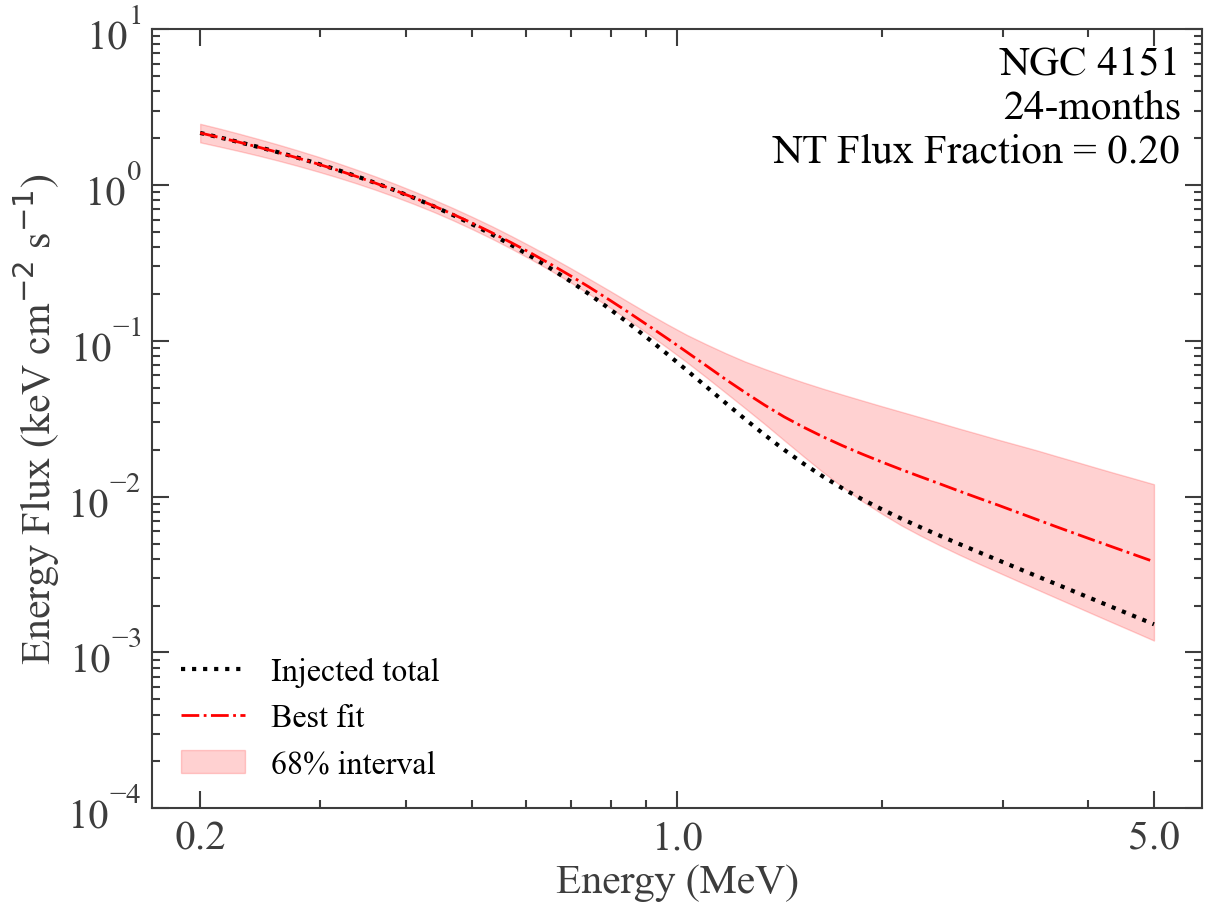

In [203]:
FONT_SIZE = 30
plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update({
    "font.weight": "550",
    "axes.titleweight": "550",
    "axes.labelweight": "550",
})


def style_axis(ax):
    ax.xaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", top=True, pad=8, labelsize=FONT_SIZE)
    ax.xaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", top=True, pad=8)
    ax.yaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", right=True, pad=8, labelsize=FONT_SIZE)
    ax.yaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", right=True, pad=8)
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)


fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)

injected_label = "Injected total" if include_nonthermal_tail else "Injected thermal"
ax.plot(energy / 1000, energy * energy * flux_inj, color="black", ls=":", lw=3, label=injected_label)

ax.plot(
    energy / 1000,
    energy * energy * primary_fit["flux_median"],
    color=primary_fit["color"],
    lw=2,
    linestyle=primary_fit["linestyle"],
    label="Best fit",
)
ax.fill_between(
    energy / 1000,
    energy * energy * primary_fit["flux_lo"],
    energy * energy * primary_fit["flux_hi"],
    alpha=0.18,
    color=primary_fit["color"],
    label="68% interval",
)
ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

ax.set_ylim(1e-4, 10)

def integrate_energy_flux(photon_flux):
    return np.trapezoid(energy * photon_flux, energy)

energy_flux_ratio = 0.0
if include_nonthermal_tail:
    thermal_flux = np.asarray([spectrum_inj_ec200.evaluate_at(e) for e in energy])
    tail_flux = np.asarray([spectrum_inj_ec200_PL.evaluate_at(e) for e in energy])
    thermal_energy_flux = integrate_energy_flux(thermal_flux)
    tail_energy_flux = integrate_energy_flux(tail_flux)
    energy_flux_ratio = tail_energy_flux / (tail_energy_flux + thermal_energy_flux)

ax.text(
    0.98,
    0.98,
    f"NGC 4151\n{exposure_months}-months\nNT Flux Fraction = {energy_flux_ratio:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=FONT_SIZE,
    fontweight="550",
)

_ = ax.legend(fontsize=23, loc="lower left", frameon=False)

print(energy_flux_ratio)


## Bin-by-bin SED (COSI-only)

This is the Paper_Plots-style SED extraction tuned for the active DC4 one-cutoff case. Each SED bin refits only the thermal normalization `K_1`; all spectral-shape parameters and the non-thermal link stay fixed, so the bin-by-bin point represents the fixed CPL+PL spectral shape scaled in that measured-energy band.


In [200]:
from astromodels import clone_model
from threeML.minimizer.minimization import LocalMinimization
from contextlib import contextmanager
import logging


@contextmanager
def _quiet_astromodels_parameter_bounds():
    parameter_logger = logging.getLogger("astromodels.core.parameter")
    old_level = parameter_logger.level
    parameter_logger.setLevel(logging.ERROR)
    try:
        yield
    finally:
        parameter_logger.setLevel(old_level)


class EnergyRangePoissonLikelihood(PoissonLikelihood):
    def __init__(self, data, response, bkg, em_slice):
        super().__init__(data, response, bkg)
        self._em_slice = em_slice

    @staticmethod
    def _hist_to_dense_array(hist):
        contents = hist.contents
        if hasattr(contents, "todense"):
            contents = contents.todense()
        if hasattr(contents, "value"):
            contents = contents.value
        return np.asarray(contents)

    @property
    def nobservations(self):
        return self._hist_to_dense_array(self._data.data.slice[{"Em": self._em_slice}]).size

    def get_log_like(self):
        expectation = self._response.expectation(copy=self.has_bkg)
        if self.has_bkg:
            expectation += self._bkg.expectation(copy=False)

        expectation = self._hist_to_dense_array(expectation.slice[{"Em": self._em_slice}])
        data = self._hist_to_dense_array(self._data.data.slice[{"Em": self._em_slice}])

        return np.nansum(data * np.log(expectation) - expectation)


def build_cosi_plugin_for_hist(data_hist_for_fit, bkg_hist_for_fit, sc_orientation, em_slice, plugin_name="cosi_sed"):
    # The current response implementation requires the full Em axis. We therefore
    # build the full response and slice only inside the likelihood, matching the
    # Paper_Plots EnergyRangeCOSILike behavior.
    data = EmCDSBinnedData(data_hist_for_fit)

    bkg_hist_for_fit = bkg_hist_for_fit.copy()
    bkg_hist_for_fit += sys.float_info.min
    bkg = FreeNormBinnedBackground(
        {"total_bkg": bkg_hist_for_fit},
        sc_history=sc_orientation,
        copy=False,
    )

    instrument_response = BinnedInstrumentResponse(dr, data)
    psr = BinnedThreeMLPointSourceResponse(
        data=data,
        instrument_response=instrument_response,
        sc_history=sc_orientation,
        energy_axis=dr.axes["Ei"],
        polarization_axis=dr.axes["Pol"] if "Pol" in dr.axes.labels else None,
        nside=2 * data.axes["PsiChi"].nside,
    )
    response = BinnedThreeMLModelFolding(data=data, point_source_response=psr)
    like_fun = EnergyRangePoissonLikelihood(data, response, bkg, em_slice=em_slice)
    cosi = ThreeMLPluginInterface(plugin_name, like_fun, response, bkg)

    for bkg_label in bkg.labels:
        cosi.bkg_parameter[bkg_label] = Parameter(
            bkg_label,
            200.0,
            min_value=0.0,
            max_value=10000.0,
            delta=0.05,
            unit=u.Hz,
        )

    return {
        "data": data,
        "bkg": bkg,
        "instrument_response": instrument_response,
        "psr": psr,
        "response": response,
        "cosi": cosi,
    }


def _iter_model_sources(model):
    return [
        (name, child)
        for name, child in getattr(model, "_children", {}).items()
        if hasattr(child, "spectrum")
    ]


def _find_shape_by_class(shape, shape_name):
    if shape is None:
        return None
    if shape.__class__.__name__ == shape_name:
        return shape
    for child_shape in getattr(shape, "functions", []):
        match = _find_shape_by_class(child_shape, shape_name)
        if match is not None:
            return match
    return None


def _get_source_spectral_shape(source, shape_name="Cutoff_powerlaw"):
    main_component = source.spectrum.main

    for attr in (shape_name, "shape", "composite"):
        candidate = getattr(main_component, attr, None)
        match = _find_shape_by_class(candidate, shape_name)
        if match is not None:
            return match

    return None


def _resolve_source_name(model, source_name=None, shape_name="Cutoff_powerlaw"):
    sources = _iter_model_sources(model)

    if source_name is not None:
        source_names = [name for name, _ in sources]
        if source_name not in source_names:
            raise ValueError(f"Source {source_name!r} is not in optimized model. Available sources: {source_names}.")
        if _get_source_spectral_shape(model[source_name], shape_name=shape_name) is None:
            raise ValueError(f"Source {source_name!r} does not contain a {shape_name} shape.")
        return source_name

    source_names = [
        name
        for name, source in sources
        if _get_source_spectral_shape(source, shape_name=shape_name) is not None
    ]
    if len(source_names) != 1:
        raise ValueError(
            f"Expected one source with a {shape_name} shape, found {source_names}. "
            "Pass source_name to select the SED target explicitly."
        )
    return source_names[0]


def _get_cutoff_powerlaw_shape_from_model(model, source_name=None):
    source_name = _resolve_source_name(model, source_name=source_name)
    return _get_source_spectral_shape(model[source_name]), source_name


def _get_cutoff_powerlaw_shape(global_results, source_name=None):
    return _get_cutoff_powerlaw_shape_from_model(global_results.optimized_model, source_name=source_name)


def build_full_sed_model(global_results, freeze_cutoff=True, source_name=None):
    best_fit_shape, source_name = _get_cutoff_powerlaw_shape(global_results, source_name=source_name)

    # clone_model recreates astromodels parameters at defaults before restoring the
    # fitted values and bounds. Suppress only those transient bound warnings.
    with _quiet_astromodels_parameter_bounds():
        sed_model = clone_model(global_results.optimized_model)
        fit_shape, _ = _get_cutoff_powerlaw_shape_from_model(sed_model, source_name=source_name)

        for parameter in sed_model.parameters.values():
            parameter.fix = True

        fit_shape.K.value = best_fit_shape.K.value
        fit_shape.K.min_value = max(best_fit_shape.K.value * 1e-3, 1e-12)
        fit_shape.K.max_value = best_fit_shape.K.value * 1e3
        fit_shape.K.fix = False

        fit_shape.index.value = best_fit_shape.index.value
        fit_shape.index.fix = True
        fit_shape.xc.value = best_fit_shape.xc.value
        fit_shape.xc.fix = freeze_cutoff

    return sed_model, source_name


def _hist_sum(hist):
    contents = hist.contents
    if hasattr(contents, "todense"):
        contents = contents.todense()
    if hasattr(contents, "value"):
        contents = contents.value
    return float(np.asarray(contents).sum())


def _evaluate_model_photon_flux(model, energy):
    photon_flux = 0.0
    for _, source in _iter_model_sources(model):
        photon_flux += float(source.spectrum.main.shape.evaluate_at(energy))
    return photon_flux


def _with_target_k_value(model, source_name, k_value, evaluator):
    target_shape = _get_source_spectral_shape(model[source_name])
    original_k = target_shape.K.value
    target_shape.K.value = float(k_value)
    try:
        return evaluator()
    finally:
        target_shape.K.value = original_k


def _integrate_model_energy_flux(model, source_name, k_value, e_min, e_max, n_points=256):
    energy_grid = np.geomspace(e_min, e_max, n_points)

    def evaluator():
        return np.asarray([_evaluate_model_photon_flux(model, energy) for energy in energy_grid])

    photon_flux = _with_target_k_value(model, source_name, k_value, evaluator)
    return float(np.trapezoid(energy_grid * photon_flux, energy_grid))


def _evaluate_model_sed_flux(model, source_name, k_value, energy):
    return _with_target_k_value(
        model,
        source_name,
        k_value,
        lambda: float(energy**2 * _evaluate_model_photon_flux(model, energy)),
    )


def _get_global_background_scale(global_results, default=200.0):
    try:
        results_frame = global_results.get_data_frame()
    except Exception:
        return float(default)

    for parameter_path in results_frame.index:
        parameter_path = str(parameter_path)
        if "total_bkg" in parameter_path or parameter_path.startswith("background_"):
            return float(results_frame.loc[parameter_path, "value"])

    return float(default)


def _run_joint_likelihood_fit(joint_likelihood, minuit_ftol=None):
    if minuit_ftol is not None:
        minuit = LocalMinimization("minuit")
        minuit.setup(ftol=float(minuit_ftol))
        joint_likelihood.set_minimizer(minuit)

    fit_status = "covariance"
    try:
        joint_likelihood.fit(quiet=True)
    except Exception as exc:
        fit_status = f"no-covariance fallback ({type(exc).__name__})"
        joint_likelihood.fit(quiet=True, compute_covariance=False)
    return fit_status


def _get_joint_likelihood_statistic(joint_likelihood):
    statistic_frame = joint_likelihood.results.get_statistic_frame()
    if "-log(likelihood)" in statistic_frame.columns:
        statistic_column = statistic_frame["-log(likelihood)"]
    else:
        numeric_frame = statistic_frame.select_dtypes(include=[np.number])
        if numeric_frame.empty:
            raise ValueError(f"No numeric statistic columns found in {list(statistic_frame.columns)}.")
        statistic_column = numeric_frame.iloc[:, 0]

    if "total" in statistic_column.index:
        return float(statistic_column.loc["total"])
    return float(statistic_column.sum())


def _ts_to_sigma(ts_value):
    if not np.isfinite(ts_value) or ts_value <= 0:
        return 0.0
    return float(np.sqrt(ts_value))


def _extract_profile_error(errors, parameter_path):
    if hasattr(errors, "index"):
        if parameter_path in errors.index:
            row = errors.loc[parameter_path]
            return float(row["negative_error"]), float(row["positive_error"])
        for row_path in errors.index:
            if str(row_path).endswith(parameter_path.split(".")[-1]):
                row = errors.loc[row_path]
                return float(row["negative_error"]), float(row["positive_error"])
    return None


def _interpolate_profile_crossing(x1, y1, x2, y2, target):
    if np.isclose(y1, y2):
        return float(0.5 * (x1 + x2))
    fraction = float((target - y1) / (y2 - y1))
    fraction = float(np.clip(fraction, 0.0, 1.0))
    if x1 > 0 and x2 > 0:
        return float(np.exp(np.log(x1) + fraction * (np.log(x2) - np.log(x1))))
    return float(x1 + fraction * (x2 - x1))


def _find_profile_crossing(x_values, delta_ts, threshold, side):
    if len(x_values) == 0:
        return None
    minimum_index = int(np.nanargmin(delta_ts))

    if side == "left":
        for index in range(minimum_index - 1, -1, -1):
            y1 = float(delta_ts[index])
            y2 = float(delta_ts[index + 1])
            if np.isnan(y1) or np.isnan(y2):
                continue
            if (y1 - threshold) * (y2 - threshold) <= 0:
                return _interpolate_profile_crossing(
                    float(x_values[index]), y1, float(x_values[index + 1]), y2, threshold
                )
        return None

    for index in range(minimum_index, len(x_values) - 1):
        y1 = float(delta_ts[index])
        y2 = float(delta_ts[index + 1])
        if np.isnan(y1) or np.isnan(y2):
            continue
        if (y1 - threshold) * (y2 - threshold) <= 0:
            return _interpolate_profile_crossing(
                float(x_values[index]), y1, float(x_values[index + 1]), y2, threshold
            )
    return None


def _manual_k_profile_interval(joint_likelihood, parameter_path, center_value, lower_bound, upper_bound, n_steps=81):
    tiny_positive = float(np.finfo(float).tiny)
    scan_min = max(float(lower_bound), tiny_positive, float(center_value) * 1e-3)
    scan_max = min(float(upper_bound), float(center_value) * 1e3) if np.isfinite(upper_bound) else float(center_value) * 1e3
    if scan_max <= scan_min:
        scan_max = max(float(center_value) * 1e3, scan_min * 1e3)

    x_values, _, profile_values, profile_figure = joint_likelihood.get_contours(
        parameter_path,
        param_1_minimum=float(scan_min),
        param_1_maximum=float(scan_max),
        param_1_n_steps=int(n_steps),
        progress=False,
        log=(True,),
    )
    plt.close(profile_figure)

    x_values = np.asarray(x_values, dtype=float)
    profile_values = np.asarray(profile_values, dtype=float)
    delta_ts = 2.0 * (profile_values - np.nanmin(profile_values))
    left_crossing = _find_profile_crossing(x_values, delta_ts, 1.0, "left")
    right_crossing = _find_profile_crossing(x_values, delta_ts, 1.0, "right")

    status = f"manual K profile ({len(x_values)} points, {scan_min:.3e}-{scan_max:.3e})"
    return left_crossing, right_crossing, status


def fit_full_cosi_sed(
    global_results,
    data_hist,
    bkg_hist,
    sc_orientation,
    source_name=None,
    n_sed_bins=4,
    freeze_cutoff=True,
    freeze_background=True,
    background_scale_value=None,
    minuit_ftol=1e-2,
    error_estimation="minos_then_manual",
    manual_k_profile_points=81,
    energy_min_keV=200,
    energy_max_keV=5000,
):
    em_edges = data_hist.axes["Em"].edges.to_value(u.keV)
    native_em_bins = np.flatnonzero((em_edges[:-1] >= energy_min_keV) & (em_edges[1:] <= energy_max_keV))

    if len(native_em_bins) == 0:
        raise ValueError(f"No native Em bins are fully contained in {energy_min_keV}-{energy_max_keV} keV.")
    if len(native_em_bins) < n_sed_bins:
        raise ValueError(f"Need at least {n_sed_bins} native bins, got {len(native_em_bins)}.")

    # Match the Paper_Plots grouping: one native bin per early SED bin, with the remainder in the last bin.
    group_sizes = [1] * (n_sed_bins - 1) + [len(native_em_bins) - (n_sed_bins - 1)]
    grouped_bins = []
    start = 0
    for group_size in group_sizes:
        grouped_bins.append(native_em_bins[start:start + group_size])
        start += group_size

    best_fit_shape, source_name = _get_cutoff_powerlaw_shape(global_results, source_name=source_name)
    global_k = float(best_fit_shape.K.value)
    frozen_index = float(best_fit_shape.index.value)
    frozen_cutoff = float(best_fit_shape.xc.value)
    global_background_scale = _get_global_background_scale(global_results, default=200.0)
    if background_scale_value is not None:
        background_scale_value = float(background_scale_value)

    sed_rows = []
    for sed_bin_index, group in enumerate(grouped_bins, start=1):
        em_slice = slice(int(group[0]), int(group[-1]) + 1)
        e_min = float(em_edges[group[0]])
        e_max = float(em_edges[group[-1] + 1])
        e_ref = float(np.sqrt(e_min * e_max))
        data_counts = _hist_sum(data_hist.slice[{"Em": em_slice}])
        background_counts = _hist_sum(bkg_hist.slice[{"Em": em_slice}])

        dataset_name = f"cosi_sed_bin_{sed_bin_index}"
        plugin_bundle = build_cosi_plugin_for_hist(data_hist.copy(), bkg_hist.copy(), sc_orientation, em_slice=em_slice, plugin_name=dataset_name)
        bin_cosi = plugin_bundle["cosi"]

        for bkg_label in plugin_bundle["bkg"].labels:
            background_parameter = bin_cosi.bkg_parameter[bkg_label]
            background_parameter.value = global_background_scale if background_scale_value is None else background_scale_value
            background_parameter.fix = bool(freeze_background)

        bin_model, source_name = build_full_sed_model(
            global_results,
            freeze_cutoff=freeze_cutoff,
            source_name=source_name,
        )
        bin_like = JointLikelihood(bin_model, DataList(bin_cosi), verbose=False)
        fit_status = _run_joint_likelihood_fit(bin_like, minuit_ftol=minuit_ftol)
        bin_results = bin_like.results
        fit_shape, _ = _get_cutoff_powerlaw_shape_from_model(bin_results.optimized_model, source_name=source_name)
        k_value = float(fit_shape.K.value)
        k_min = float(fit_shape.K.min_value) if fit_shape.K.min_value is not None else 0.0
        k_max = float(fit_shape.K.max_value) if fit_shape.K.max_value is not None else np.inf
        k_path = fit_shape.K.path
        joint_statistic = _get_joint_likelihood_statistic(bin_like)

        null_model, _ = build_full_sed_model(global_results, freeze_cutoff=freeze_cutoff, source_name=source_name)
        null_shape, _ = _get_cutoff_powerlaw_shape_from_model(null_model, source_name=source_name)
        null_k_value = max(k_min, np.finfo(float).tiny)
        with _quiet_astromodels_parameter_bounds():
            null_shape.K.min_value = min(float(null_shape.K.min_value or null_k_value), null_k_value)
            null_shape.K.value = null_k_value
            null_shape.K.fix = True

        null_plugin_bundle = build_cosi_plugin_for_hist(
            data_hist.copy(),
            bkg_hist.copy(),
            sc_orientation,
            em_slice=em_slice,
            plugin_name=f"{dataset_name}_null",
        )
        null_cosi = null_plugin_bundle["cosi"]
        for bkg_label in null_plugin_bundle["bkg"].labels:
            background_parameter = null_cosi.bkg_parameter[bkg_label]
            background_parameter.value = global_background_scale if background_scale_value is None else background_scale_value
            background_parameter.fix = bool(freeze_background)

        null_like = JointLikelihood(null_model, DataList(null_cosi), verbose=False)
        null_fit_status = _run_joint_likelihood_fit(null_like, minuit_ftol=minuit_ftol)
        joint_null_statistic = _get_joint_likelihood_statistic(null_like)
        ts_value_raw = 2.0 * (joint_null_statistic - joint_statistic)
        ts_value = max(0.0, ts_value_raw)
        sigma = _ts_to_sigma(ts_value)

        k_lo = None
        k_hi = None
        profile_error_status = "not run"
        error_source = "none"

        if error_estimation in ("minos", "minos_then_manual"):
            try:
                errors = bin_like.get_errors(quiet=True)
                interval = _extract_profile_error(errors, k_path)
                if interval is not None:
                    neg_error, pos_error = interval
                    k_lo = max(k_min, k_value + neg_error)
                    k_hi = min(k_max, k_value + pos_error) if np.isfinite(k_max) else k_value + pos_error
                    profile_error_status = "minos ok"
                    error_source = "minos"
            except Exception as exc:
                profile_error_status = f"minos failed ({type(exc).__name__})"

        if (k_lo is None or k_hi is None) and error_estimation in ("manual_profile", "minos_then_manual"):
            try:
                left_crossing, right_crossing, manual_status = _manual_k_profile_interval(
                    bin_like,
                    k_path,
                    k_value,
                    k_min,
                    k_max,
                    n_steps=manual_k_profile_points,
                )
                if left_crossing is not None:
                    k_lo = left_crossing
                if right_crossing is not None:
                    k_hi = right_crossing
                profile_error_status = f"{profile_error_status}; {manual_status}"
                error_source = "manual_profile"
            except Exception as exc:
                profile_error_status = f"{profile_error_status}; manual failed ({type(exc).__name__})"

        if k_lo is None:
            k_lo = k_min
        if k_hi is None:
            k_hi = k_value * 3.0 if k_value > 0 else max(k_min * 10.0, 1e-12)
            error_source = "manual upper limit"

        integrated_flux = _integrate_model_energy_flux(bin_results.optimized_model, source_name, k_value, e_min, e_max)
        integrated_flux_lo = _integrate_model_energy_flux(bin_results.optimized_model, source_name, k_lo, e_min, e_max)
        integrated_flux_hi = _integrate_model_energy_flux(bin_results.optimized_model, source_name, k_hi, e_min, e_max)
        sed_flux = _evaluate_model_sed_flux(bin_results.optimized_model, source_name, k_value, e_ref)
        sed_flux_lo = _evaluate_model_sed_flux(bin_results.optimized_model, source_name, k_lo, e_ref)
        sed_flux_hi = _evaluate_model_sed_flux(bin_results.optimized_model, source_name, k_hi, e_ref)
        has_two_sided_error = bool(k_lo > k_min and k_hi > k_value)
        is_upper_limit = bool(error_source == "manual upper limit" or (not has_two_sided_error) or ts_value < 4.0)

        sed_rows.append(
            {
                "bin_index": sed_bin_index,
                "source_name": source_name,
                "e_min_keV": e_min,
                "e_max_keV": e_max,
                "e_ref_keV": e_ref,
                "bin_energy_flux_keV_cm2_s": integrated_flux,
                "bin_energy_flux_lo_keV_cm2_s": integrated_flux_lo,
                "bin_energy_flux_hi_keV_cm2_s": integrated_flux_hi,
                "sed_keV_cm2_s": sed_flux,
                "sed_lo_keV_cm2_s": sed_flux_lo,
                "sed_hi_keV_cm2_s": sed_flux_hi,
                "source_K": k_value,
                "source_K_lo": k_lo,
                "source_K_hi": k_hi,
                "source_K_over_global": k_value / global_k if global_k > 0 else np.nan,
                "background_scale": global_background_scale if background_scale_value is None else background_scale_value,
                "background_requested_fixed": freeze_background,
                "data_counts": data_counts,
                "background_counts": background_counts,
                "excess_counts": data_counts - background_counts,
                "joint_statistic": joint_statistic,
                "joint_null_statistic": joint_null_statistic,
                "ts_value_raw": ts_value_raw,
                "ts_value": ts_value,
                "sigma": sigma,
                "fit_status": fit_status,
                "null_fit_status": null_fit_status,
                "profile_error_status": profile_error_status,
                "error_source": error_source,
                "minuit_ftol": minuit_ftol,
                "error_estimation": error_estimation,
                "hit_parameter_bound": bool(np.isclose(k_value, k_min) or (np.isfinite(k_max) and np.isclose(k_value, k_max))),
                "is_upper_limit": is_upper_limit,
                "frozen_index": frozen_index,
                "frozen_cutoff_keV": frozen_cutoff,
            }
        )

    return pd.DataFrame(sed_rows)


In [201]:
results_sed = primary_fit["results"]
data_sed_hist = data_hist.copy()
bkg_sed_hist = total_bkg.copy()

n_full_sed_bins = 4
full_cosi_sed_df = fit_full_cosi_sed(
    global_results=results_sed,
    data_hist=data_sed_hist,
    bkg_hist=bkg_sed_hist,
    sc_orientation=sc_orientation,
    source_name="ngc4151",
    n_sed_bins=n_full_sed_bins,
    freeze_cutoff=True,
    freeze_background=True,
    minuit_ftol=1e-2,
    error_estimation="minos_then_manual",
    manual_k_profile_points=81,
    energy_min_keV=200,
    energy_max_keV=5000,
)

sed_summary_columns = [
    "bin_index",
    "e_min_keV",
    "e_max_keV",
    "e_ref_keV",
    "sed_keV_cm2_s",
    "sed_lo_keV_cm2_s",
    "sed_hi_keV_cm2_s",
    "ts_value",
    "sigma",
    "is_upper_limit",
]
display(full_cosi_sed_df[sed_summary_columns])

diagnostic_columns = [
    "bin_index",
    "source_K",
    "source_K_lo",
    "source_K_hi",
    "source_K_over_global",
    "background_scale",
    "data_counts",
    "background_counts",
    "excess_counts",
    "fit_status",
    "null_fit_status",
    "profile_error_status",
    "error_source",
    "hit_parameter_bound",
]
display(full_cosi_sed_df[diagnostic_columns])


         WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=174483;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=301978;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc_1 (10.0) was below the new minimum 100.0. ]8;id=313233;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=188202;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

         WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=411459;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=428122;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc_1 (10.0) was below the new minimum 100.0. ]8;id=405341;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=117246;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

         WARNING   External parameter total_bkg already exist in the model. Overwriting it...          ]8;id=682603;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/model.py\model.py]8;;\:]8;id=570276;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/model.py#593\593]8;;\

...

         WARNING   The current value of the parameter xc_1 (10.0) was below the new minimum 100.0. ]8;id=103887;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=765126;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

         WARNING   The current value of the parameter K_1 (1.0) was above the new maximum          ]8;id=885069;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=229435;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\
                  0.10789498656476243.                                                                             

         WARNING   The current value of the parameter xc_1 (10.0) was below the new minimum 100.0. ]8;id=448620;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=534176;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

,bin_index,e_min_keV,e_max_keV,e_ref_keV,sed_keV_cm2_s,sed_lo_keV_cm2_s,sed_hi_keV_cm2_s,ts_value,sigma,is_upper_limit
0,1,251.189,398.107,316.227923,1.258737,1.211681,1.305797,787.754429,28.066963,False
1,2,398.107,630.957,501.186989,0.558874,0.517018,0.590859,106.681560,10.328677,False
2,3,630.957,1000.000,794.328018,0.163860,0.084330,0.245464,7.000733,2.645890,False
3,4,1000.000,3981.070,1995.261888,0.010707,0.000050,0.048414,1.241650,1.114294,True


,bin_index,source_K,source_K_lo,source_K_hi,source_K_over_global,background_scale,data_counts,background_counts,excess_counts,fit_status,null_fit_status,profile_error_status,error_source,hit_parameter_bound
0,1,0.000108,1.042442e-04,0.000112,1.003685,213.045937,4.408812e+07,43957272.0,130847.906431,covariance,covariance,minos ok,minos,False
1,2,0.000108,9.970471e-05,0.000114,0.998901,213.045937,2.974229e+07,29709944.0,32348.866794,covariance,covariance,minos failed (MINOSFailed); manual K profile (...,manual_profile,False
2,3,0.000102,5.248109e-05,0.000153,0.945132,213.045937,1.922275e+07,19217704.0,5049.781496,covariance,covariance,minos ok,minos,False
3,4,0.000069,3.261466e-07,0.000314,0.643886,213.045937,3.000669e+07,30006088.0,599.209096,covariance,covariance,minos ok,minos,False


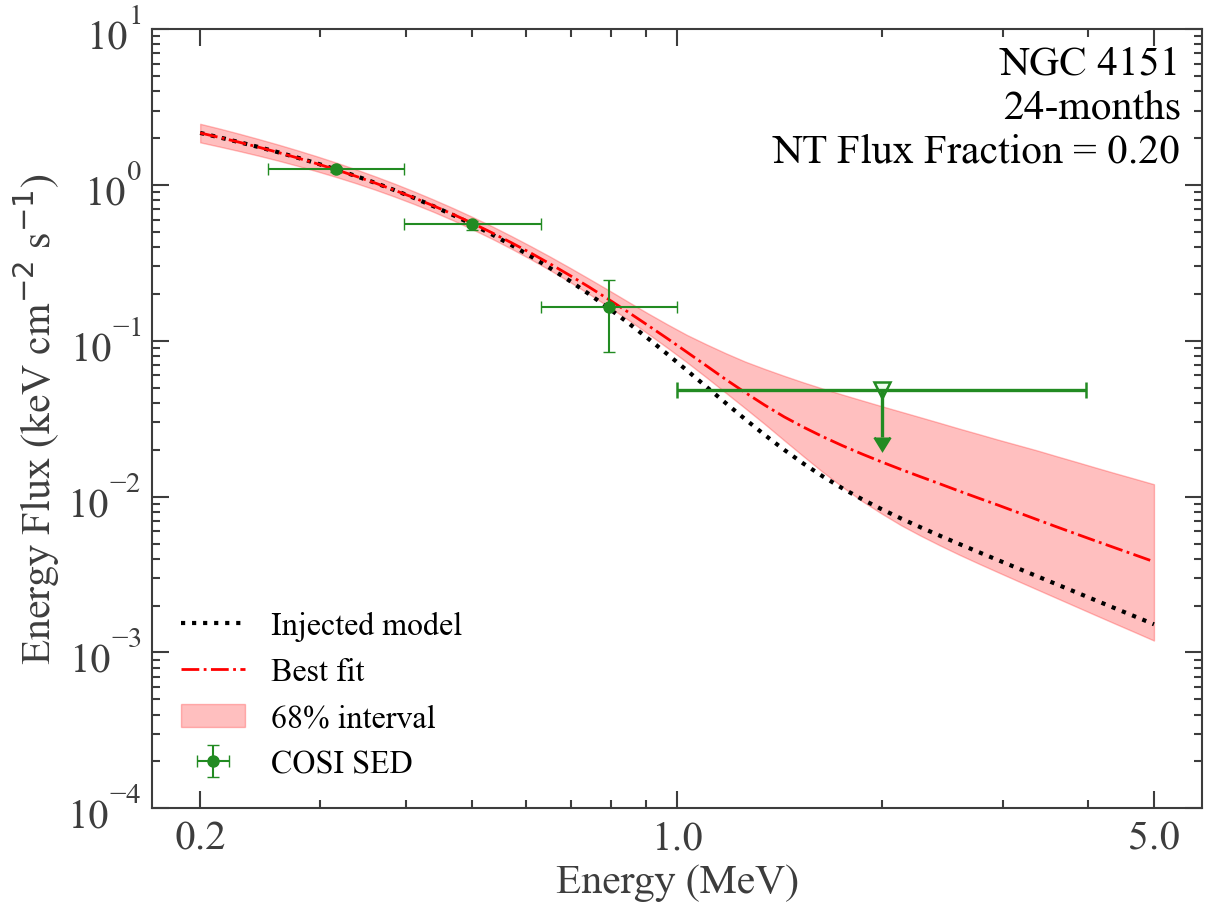

: 

In [ ]:
def _make_xerr(df):
    return np.vstack(
        [
            df["e_ref_keV"] - df["e_min_keV"],
            df["e_max_keV"] - df["e_ref_keV"],
        ]
    )


def _split_sed_detections(df, ts_threshold=4.0):
    upper_limit_mask = df["is_upper_limit"].copy()
    if "ts_value" in df.columns:
        upper_limit_mask = upper_limit_mask | (df["ts_value"] < ts_threshold)
    return df.loc[~upper_limit_mask].copy(), df.loc[upper_limit_mask].copy()


fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)

detections, upper_limits = _split_sed_detections(full_cosi_sed_df)
n_sed_bins = len(full_cosi_sed_df)

ax.plot(
    energy / 1000,
    energy * energy * flux_inj,
    color="black",
    ls=":",
    lw=3,
    label="Injected model",
)
ax.plot(
    energy / 1000,
    energy * energy * primary_fit["flux_median"],
    color=primary_fit["color"],
    lw=2,
    linestyle=primary_fit["linestyle"],
    label="Best fit",
)
ax.fill_between(
    energy / 1000,
    energy * energy * primary_fit["flux_lo"],
    energy * energy * primary_fit["flux_hi"],
    alpha=0.25,
    color=primary_fit["color"],
    label="68% interval",
)

if not detections.empty:
    detection_xerr = _make_xerr(detections) / 1000
    detection_yerr = np.vstack(
        [
            np.maximum(detections["sed_keV_cm2_s"] - detections["sed_lo_keV_cm2_s"], 0),
            np.maximum(detections["sed_hi_keV_cm2_s"] - detections["sed_keV_cm2_s"], 0),
        ]
    )
    ax.errorbar(
        detections["e_ref_keV"] / 1000,
        detections["sed_keV_cm2_s"],
        xerr=detection_xerr,
        yerr=detection_yerr,
        fmt="o",
        color="forestgreen",
        ecolor="forestgreen",
        elinewidth=1.5,
        capsize=4,
        markersize=8,
        label=f"COSI SED",
    )

if not upper_limits.empty:
    upper_xerr = _make_xerr(upper_limits) / 1000
    upper_y = upper_limits["sed_hi_keV_cm2_s"].to_numpy()
    upper_yerr = np.maximum(0.5 * upper_y, np.finfo(float).tiny)
    ax.errorbar(
        upper_limits["e_ref_keV"] / 1000,
        upper_y,
        xerr=upper_xerr,
        yerr=upper_yerr,
        uplims=True,
        fmt="v",
        color="forestgreen",
        ecolor="forestgreen",
        markerfacecolor="honeydew",
        markeredgecolor="forestgreen",
        markeredgewidth=1.8,
        elinewidth=2.4,
        capsize=6,
        markersize=11,
        barsabove=True,
        zorder=6,
        label="Upper limits" if detections.empty else "_nolegend_",
    )

ax.text(
    0.98,
    0.98,
    f"NGC 4151\n{exposure_months}-months\nNT Flux Fraction = {energy_flux_ratio:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=FONT_SIZE,
    fontweight="550",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-4, 10)
ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))
ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)
ax.legend(fontsize=23, loc="lower left", frameon=False)


Plot the fitted spectrum convolved with the response plus the fitted background, as well as the simulated source+background counts.
